In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,accuracy_score,classification_report,confusion_matrix


In [ ]:
data = pd.read_csv('/content/CollegePlacement (1).csv')

In [ ]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [ ]:
data['Communication_Skills'].max()

10

In [ ]:
data.shape

(10000, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [ ]:
# need to change categorical data [Internship_Experience] and [Placement] to numerical
# so we use label encoder ( task-1 ML class )

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_cp = data.copy()

data_cp['Internship_Experience'] = le.fit_transform(data_cp['Internship_Experience'])
data_cp['Placement'] = le.fit_transform(data_cp['Placement'])

In [ ]:
data_cp.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


In [ ]:
data_cp.drop('College_ID',axis=1,inplace=True)

In [ ]:
data_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10000 non-null  int64  
 1   Prev_Sem_Result         10000 non-null  float64
 2   CGPA                    10000 non-null  float64
 3   Academic_Performance    10000 non-null  int64  
 4   Internship_Experience   10000 non-null  int64  
 5   Extra_Curricular_Score  10000 non-null  int64  
 6   Communication_Skills    10000 non-null  int64  
 7   Projects_Completed      10000 non-null  int64  
 8   Placement               10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


In [ ]:
# checks for any null values present or not
data_cp.isnull().sum()

,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


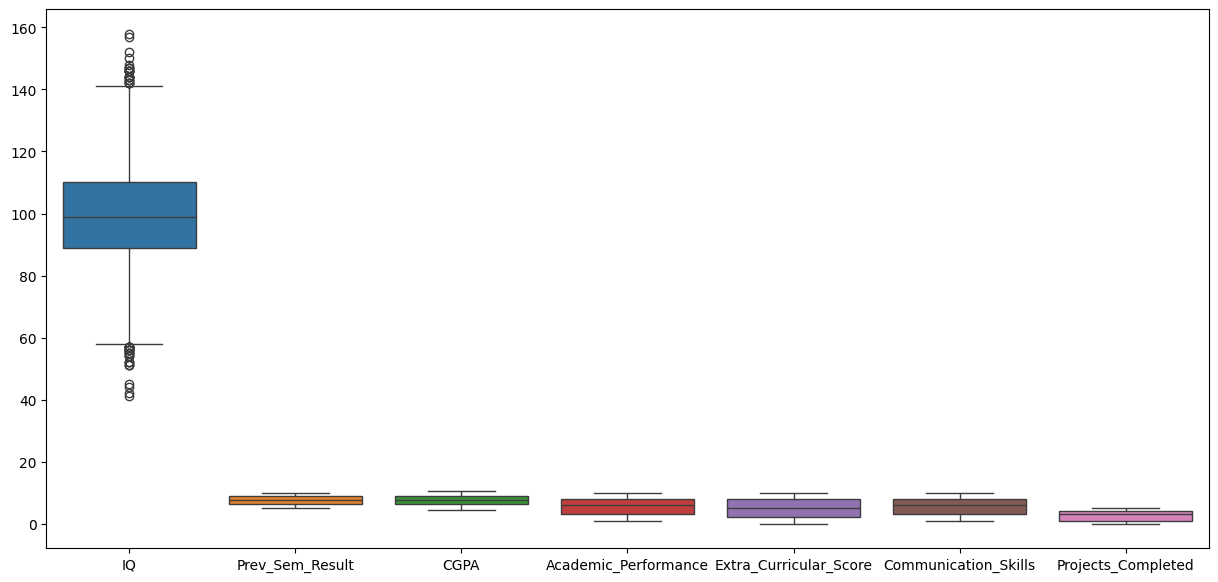

In [ ]:
# shows the outliers in IQ column
plt.figure(figsize=(15,7))
sns.boxplot(data=data)
plt.show()

In [ ]:
X = data_cp.drop(['Placement'],axis = 1)
Y = data_cp['Placement']

X.shape,Y.shape

((10000, 8), (10000,))

In [ ]:
# split the dataset into training and testing sets

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42,shuffle=True)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((7000, 8), (3000, 8), (7000,), (3000,))

In [ ]:
# define parameter grid for hyperparmater tuning

# ??

# Logistic Model

In [ ]:
model = LogisticRegression()
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Predict
Y_pred = model.predict(X_test)

In [ ]:
print("Accuracy :  ",accuracy_score(Y_test,Y_pred))

Accuracy :   0.8906666666666667


In [ ]:
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2396  115]
 [ 213  276]]


In [ ]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2511
           1       0.71      0.56      0.63       489

    accuracy                           0.89      3000
   macro avg       0.81      0.76      0.78      3000
weighted avg       0.88      0.89      0.89      3000



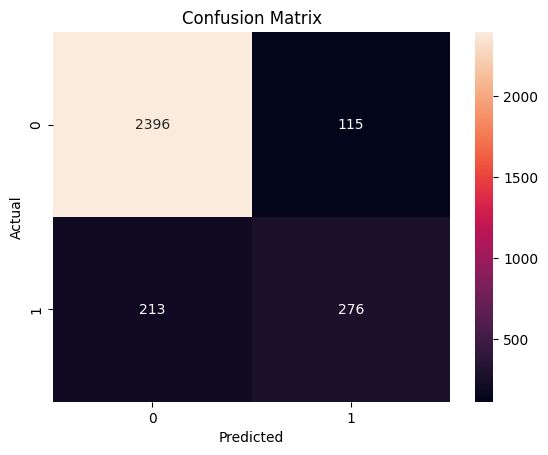

In [ ]:
# Confusion Matrix Heatmap

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Create a new data point with similar structure to X_test
new_data_point = pd.DataFrame({
    'IQ': [140],
    'Prev_Sem_Result': 5.5,
    'CGPA': [5.8],
    'Academic_Performance': [3],
    'Internship_Experience': [1], # 1 for Yes, 0 for No
    'Extra_Curricular_Score': [5],
    'Communication_Skills': [7],
    'Projects_Completed': [4]
})

# Predict the placement for the new data point
predicted_placement = model.predict(new_data_point)

# Print the predicted placement
if predicted_placement[0] == 1:
    print("Predicted Placement: Yes")
else:
    print("Predicted Placement: No")

Predicted Placement: Yes


# Descision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,Y_train)

DecisionTreeClassifier()

In [ ]:
# Accuracy

dt_pred = dt.predict(X_test)

print("Accuracy :  ",accuracy_score(Y_test,dt_pred))

Accuracy :   1.0


In [ ]:
cm1 = confusion_matrix(Y_test, dt_pred)
print("Confusion Matrix:\n", cm1)

Confusion Matrix:
 [[2511    0]
 [   0  489]]


In [ ]:
print(classification_report(Y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2511
           1       1.00      1.00      1.00       489

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



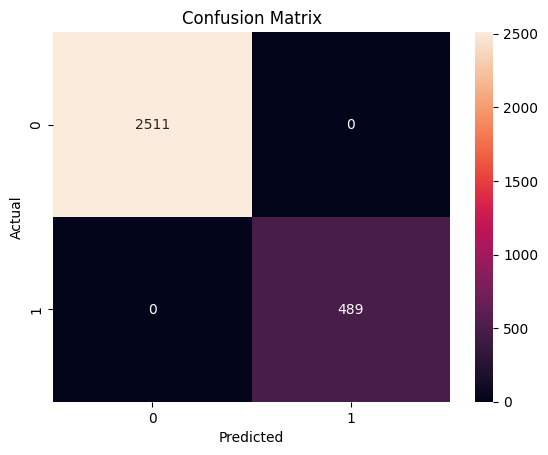

In [ ]:
# Confusion Matrix Heatmap

sns.heatmap(cm1, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Create a new data point with similar structure to X_test
new_data_point1 = pd.DataFrame({
    'IQ': [180],
    'Prev_Sem_Result': 7.5,
    'CGPA': [5.8],
    'Academic_Performance': [5],
    'Internship_Experience': [0], # 1 for Yes, 0 for No
    'Extra_Curricular_Score': [2],
    'Communication_Skills': [9],
    'Projects_Completed': [0]
})

# Predict the placement for the new data point
predicted_placement1 = dt.predict(new_data_point1)

# Print the predicted placement
if predicted_placement1[0] == 1:
    print("Predicted Placement: Yes")
else:
    print("Predicted Placement: No")

Predicted Placement: No


In [ ]:
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("sklearn",sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1


In [ ]:
import pickle
with open('model.pkl','wb') as files:
  pickle.dump(dt, files)